# HW3: Deep Learning

In this homework you will implement the following **from scratch**:

1. **Backpropagation building blocks** — forward and backward passes for linear layers, ReLU, softmax, and cross-entropy loss (NumPy)
2. **Multi-layer Perceptron (MLP)** — a full neural network class for classification (NumPy)
3. **Training loop with SGD** — stochastic gradient descent optimizer and training function (NumPy)
4. **PyTorch MLP** — reimplement the same MLP using PyTorch's `nn.Module`
5. **Attention mechanism** — scaled dot-product attention and multi-head attention (PyTorch)
6. **Transformer block** — self-attention + feed-forward with residual connections and layer norm (PyTorch)
7. **Transformer language model** — a simple character-level transformer trained on a tiny text corpus (PyTorch)

Each section starts with small **building-block exercises** that you will later combine into a full class implementation.

**Canvas Submission:**
- Upload only this notebook with the solutions. Do not upload any additional files!

**Grading:**
- You grade for the task == proportion of passed tests at the end

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from dl_helpers import (
    generate_spiral_data,
    generate_tiny_text_data,
    encode_text,
    decode_text,
    plot_decision_boundary_2d,
    plot_training_loss,
    plot_numpy_vs_torch_comparison,
    plot_attention_weights,
    plot_transformer_training,
)

from dl_tests import (
    check_numpy_mlp,
    check_torch_mlp,
    check_multi_head_attention,
    check_transformer_block,
    check_simple_transformer,
    run_single_test,
    run_tests,
)

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["font.size"] = 12

---
## Section 1: Backpropagation from Scratch

Neural networks learn by **backpropagation** — computing gradients of the loss with respect to each parameter by applying the **chain rule** backwards through the network.

We will implement forward and backward passes for each building block:
- **Linear layer**: $\text{out} = X W + b$
- **ReLU activation**: $\text{out} = \max(0, X)$
- **Softmax**: converts logits to probabilities
- **Cross-entropy loss**: measures how far predictions are from true labels

Let's build each piece step by step!

### Exercise 1.1: Linear Layer Forward Pass

Implement the forward pass of a linear (fully connected) layer: $\text{out} = X W + b$

In [2]:
def linear_forward(X, W, b):
    """Compute forward pass of a linear layer output.

    Parameters
    ----------
    X : np.ndarray of shape (batch_size, in_features)
    W : np.ndarray of shape (in_features, out_features)
    b : np.ndarray of shape (out_features,)

    Returns
    -------
    out : np.ndarray of shape (batch_size, out_features)
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement linear_forward")

    return X @ W + b

In [3]:
try:
    X_test = np.array([[1.0, 2.0], [3.0, 4.0]])
    W_test = np.array([[0.5, -0.5], [0.5, 0.5]])
    b_test = np.array([1.0, 0.0])
    out = linear_forward(X_test, W_test, b_test)
    assert out.shape == (2, 2), f"Expected shape (2, 2), got {out.shape}"
    assert np.allclose(out, [[2.5, 0.5], [4.5, 0.5]]), f"Wrong values: {out}"
    print("linear_forward tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

linear_forward tests passed! ✓


### Exercise 1.2: ReLU Forward Pass

Implement the ReLU activation function: $\text{out} = \max(0, X)$

In [11]:
def relu_forward(X):
    """Compute forward pass of ReLU activation: out = max(0, X).

    Parameters
    ----------
    X : np.ndarray of any shape

    Returns
    -------
    out : np.ndarray of same shape as X
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement relu_forward")
    return np.maximum(0, X)

In [13]:
try:
    x = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
    out = relu_forward(x)
    assert np.allclose(out, [0, 0, 0, 1, 2]), f"Wrong ReLU output: {out}"
    print("relu_forward tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

relu_forward tests passed! ✓


### Exercise 1.3: Linear Layer Backward Pass

Implement the backward pass of a linear layer. Given the gradient of the loss w.r.t. the output (`dout`), compute gradients w.r.t. the input, weights, and bias.

**Hint:** Using the chain rule:
- $\frac{\partial L}{\partial X} = \text{dout} \cdot W^T$
- $\frac{\partial L}{\partial W} = X^T \cdot \text{dout}$
- $\frac{\partial L}{\partial b} = \sum_{\text{batch}} \text{dout}$

In [16]:
def linear_backward(dout, X, W):
    """Compute backward pass of a linear layer.

    Parameters
    ----------
    dout : np.ndarray of shape (batch_size, out_features)
        Gradient of loss w.r.t. output of this layer.
    X : np.ndarray of shape (batch_size, in_features)
        Input to this layer (saved during forward pass).
    W : np.ndarray of shape (in_features, out_features)
        Weight matrix.

    Returns
    -------
    dX : np.ndarray of shape (batch_size, in_features)
    dW : np.ndarray of shape (in_features, out_features)
    db : np.ndarray of shape (out_features,)
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement linear_backward")
    dX = dout @ W.T
    dW = X.T @ dout
    db = np.sum(dout, axis=0)
    return dX, dW, db

In [17]:
try:
    np.random.seed(0)
    X = np.random.randn(4, 3)
    W = np.random.randn(3, 2)
    b = np.random.randn(2)
    dout = np.random.randn(4, 2)
    dX, dW, db = linear_backward(dout, X, W)
    assert dX.shape == X.shape, f"dX shape: expected {X.shape}, got {dX.shape}"
    assert dW.shape == W.shape, f"dW shape: expected {W.shape}, got {dW.shape}"
    assert db.shape == b.shape, f"db shape: expected {b.shape}, got {db.shape}"
    eps = 1e-5
    dW_num = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            W_plus = W.copy()
            W_plus[i, j] += eps
            W_minus = W.copy()
            W_minus[i, j] -= eps
            out_plus = linear_forward(X, W_plus, b)
            out_minus = linear_forward(X, W_minus, b)
            dW_num[i, j] = np.sum((out_plus - out_minus) * dout) / (2 * eps)
    assert np.allclose(dW, dW_num, atol=1e-6), "dW numerical gradient check failed"
    print("linear_backward tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

linear_backward tests passed! ✓


### Exercise 1.4: ReLU Backward Pass

Implement the backward pass of ReLU. The gradient flows through only where the input was positive.

**Hint:** $\frac{\partial \text{ReLU}}{\partial X} = \begin{cases} 1 & \text{if } X > 0 \\ 0 & \text{otherwise} \end{cases}$

In [18]:
def relu_backward(dout, X):
    """Compute backward pass of ReLU.

    Parameters
    ----------
    dout : np.ndarray of any shape
        Gradient of loss w.r.t. output.
    X : np.ndarray of same shape as dout
        Input to ReLU (saved during forward pass).

    Returns
    -------
    dX : np.ndarray of same shape
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement relu_backward")
    dX = dout.copy()
    dX[X <= 0] = 0
    
    return dX

In [19]:
try:
    x = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
    dout = np.array([1.0, 1.0, 1.0, 1.0, 1.0])
    dx = relu_backward(dout, x)
    assert np.allclose(dx, [0, 0, 0, 1, 1]), f"Wrong ReLU backward: {dx}"
    print("relu_backward tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

relu_backward tests passed! ✓


### Exercise 1.5: Softmax

Implement the softmax function that converts logits to probabilities.

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

**Important:** For numerical stability, subtract the maximum value from each row before exponentiating:
$\text{softmax}(z) = \text{softmax}(z - \max(z))$

In [20]:
def softmax(logits):
    """Compute softmax probabilities (numerically stable).

    Parameters
    ----------
    logits : np.ndarray of shape (batch_size, n_classes)

    Returns
    -------
    probs : np.ndarray of shape (batch_size, n_classes)
        Each row sums to 1.
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement softmax")

    # Subtract max for numerical stability
    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(shifted_logits)
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    return probs

In [21]:
try:
    logits = np.array([[1.0, 2.0, 3.0], [1.0, 1.0, 1.0]])
    probs = softmax(logits)
    assert probs.shape == (2, 3)
    assert np.allclose(probs.sum(axis=1), [1.0, 1.0]), "Rows must sum to 1"
    assert np.allclose(probs[1, 0], probs[1, 1]), "Equal logits should give equal probs"
    big_logits = np.array([[1000.0, 1001.0, 1002.0]])
    big_probs = softmax(big_logits)
    assert not np.any(np.isnan(big_probs)), "Softmax should handle large values"
    print("softmax tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

softmax tests passed! ✓


### Exercise 1.6: Cross-Entropy Loss (Forward + Backward)

Implement the cross-entropy loss and its gradient w.r.t. the **logits** (pre-softmax values).

**Loss:** $L = -\frac{1}{N} \sum_{i=1}^{N} \log(p_{i, y_i})$ where $p$ are softmax probabilities.

**Gradient shortcut:** For the combined softmax + cross-entropy, the gradient w.r.t. logits has a beautifully simple form:
$$\frac{\partial L}{\partial z} = \frac{1}{N}(p - \text{one\_hot}(y))$$

In [27]:
def cross_entropy_loss(probs, y):
    """Compute cross-entropy loss and gradient w.r.t. logits.

    Parameters
    ----------
    probs : np.ndarray of shape (batch_size, n_classes)
        Softmax probabilities.
    y : np.ndarray of shape (batch_size,)
        Integer class labels.

    Returns
    -------
    loss : float
        Average cross-entropy loss.
    dlogits : np.ndarray of shape (batch_size, n_classes)
        Gradient of loss w.r.t. logits (pre-softmax).
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement cross_entropy_loss")

    batch_size = probs.shape[0]
    correct_logprobs = -np.log(probs[np.arange(batch_size), y])
    loss = np.mean(correct_logprobs)
    dlogits = probs.copy()
    dlogits[np.arange(batch_size), y] -= 1
    dlogits /= batch_size

    return loss, dlogits



In [28]:
try:
    probs = np.array([[0.7, 0.2, 0.1], [0.1, 0.8, 0.1]])
    y = np.array([0, 1])
    loss, dlogits = cross_entropy_loss(probs, y)
    assert isinstance(loss, float), "Loss should be a float"
    assert dlogits.shape == probs.shape, f"dlogits shape mismatch"
    assert loss < 0.5, f"Loss too high for correct predictions: {loss}"
    print("cross_entropy_loss tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

cross_entropy_loss tests passed! ✓


---
## Section 2: MLP for Classification (NumPy)

Now combine the building blocks into a **multi-layer perceptron** (MLP):

$$\text{Input} \xrightarrow{\text{Linear}} \xrightarrow{\text{ReLU}} \xrightarrow{\text{Linear}} \xrightarrow{\text{ReLU}} \cdots \xrightarrow{\text{Linear}} \xrightarrow{\text{Softmax}} \text{Probabilities}$$

The `forward` method chains these operations and caches intermediate values. The `backward` method reverses through the cache to compute gradients.

### Exercise 2.1: NumpyMLP Class

Implement the `forward` and `backward` methods using the building blocks from Section 1.

**Forward pass:** For each layer $i$:
1. $z_i = \text{linear\_forward}(a_{i-1}, W_i, b_i)$
2. $a_i = \text{relu\_forward}(z_i)$ (except last layer)
3. Last layer: $\text{probs} = \text{softmax}(z_{\text{last}})$

**Backward pass:** Reverse through the cached values:
1. Start with `dlogits` from `cross_entropy_loss`
2. For each layer in reverse: `linear_backward` → `relu_backward`

In [33]:
class NumpyMLP:
    """Multi-layer perceptron implemented from scratch with NumPy.

    Architecture: Linear -> ReLU -> Linear -> ReLU -> ... -> Linear -> Softmax

    Parameters
    ----------
    layer_sizes : list of int
        Sizes of each layer including input and output.
        Example: [2, 16, 16, 3] means 2 inputs, two hidden layers of 16, 3 outputs.
    seed : int, default=42
        Random seed for weight initialization.
    """

    def __init__(self, layer_sizes, seed=42):
        self.layer_sizes = layer_sizes
        self.params = {}
        self.cache = {}

        np.random.seed(seed)
        for i in range(len(layer_sizes) - 1):
            # He initialization
            scale = np.sqrt(2.0 / layer_sizes[i])
            self.params[f"W{i}"] = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * scale
            self.params[f"b{i}"] = np.zeros(layer_sizes[i + 1])

    def forward(self, X):
        """Forward pass through the network.

        Parameters
        ----------
        X : np.ndarray of shape (batch_size, input_size)

        Returns
        -------
        probs : np.ndarray of shape (batch_size, n_classes)
        """
        # YOUR CODE HERE
        # Use linear_forward, relu_forward, softmax from above
        # Store intermediate values in self.cache for backward pass
        # raise NotImplementedError("Implement NumpyMLP.forward")
        out = X
        self.cache["X0"] = X
        for i in range(len(self.layer_sizes) - 2):
            W = self.params[f"W{i}"]
            b = self.params[f"b{i}"]
            out = linear_forward(out, W, b)
            self.cache[f"Z{i}"] = out
            out = relu_forward(out)
            self.cache[f"A{i}"] = out

        W_last = self.params[f"W{len(self.layer_sizes) - 2}"]
        b_last = self.params[f"b{len(self.layer_sizes) - 2}"]
        logits = linear_forward(out, W_last, b_last)
        self.cache["Z_last"] = logits
        probs = softmax(logits)
        return probs

    def backward(self, dlogits):
        """Backward pass through the network.

        Parameters
        ----------
        dlogits : np.ndarray of shape (batch_size, n_classes)
            Gradient from cross_entropy_loss.

        Returns
        -------
        grads : dict
            Gradients for each parameter: {"W0": ..., "b0": ..., "W1": ..., ...}
        """
        # YOUR CODE HERE
        # Use linear_backward, relu_backward from above
        # raise NotImplementedError("Implement NumpyMLP.backward")

        grads = {}
        dout = dlogits
        for i in reversed(range(len(self.layer_sizes) - 1)):
            W = self.params[f"W{i}"]
            b = self.params[f"b{i}"]
            if i == len(self.layer_sizes) - 2:
                X = self.cache[f"A{i-1}"] if i > 0 else self.cache["X0"]
                dX, dW, db = linear_backward(dout, X, W)
            else:
                Z = self.cache[f"Z{i}"]
                dZ = relu_backward(dout, Z)
                X = self.cache[f"A{i-1}"] if i > 0 else self.cache["X0"]
                dX, dW, db = linear_backward(dZ, X, W)

            grads[f"W{i}"] = dW
            grads[f"b{i}"] = db
            dout = dX

        return grads

    def predict(self, X):
        """Predict class labels."""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

Let's generate some **spiral data** — a classic 2D classification problem with 3 interleaving spirals:

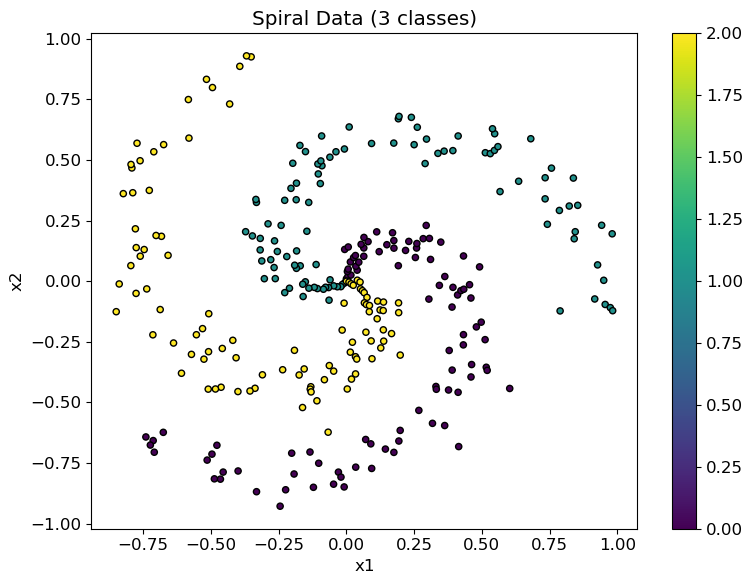

In [34]:
try:
    X_train, y_train = generate_spiral_data(n_samples=300, n_classes=3, seed=42)
    plot_decision_boundary_2d(X_train, y_train, title="Spiral Data (3 classes)")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

### Run Tests for NumpyMLP

Testing NumpyMLP...


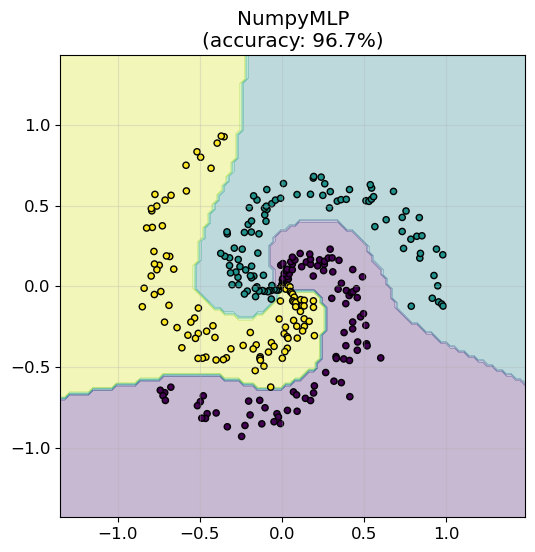

  ✓ forward_shape
  ✓ backward_shapes
  ✓ gradient_check
  ✓ training_loss_decreases
  ✓ accuracy

NumpyMLP: 5/5 tests passed
🎉 All tests passed!


In [35]:
try:
    run_single_test(NumpyMLP, check_numpy_mlp)
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

---
## Section 3: Training Loop with GD

Now that we have a model that can compute forward and backward passes, we need to **update the parameters** to minimize the loss.

**Stochastic Gradient Descent (SGD):** The simplest optimizer — update each parameter in the direction opposite to its gradient:
$$\theta_{\text{new}} = \theta_{\text{old}} - \eta \cdot \nabla_\theta L$$

where $\eta$ is the learning rate.

Neural networks are typically trained with dataset split in batches. In this exercise, you will compute gradients for the entire corpus of data which is sometimes called gradient descent - without the stochastic part.

### Exercise 3.1: GD Step

In [36]:
def gd_step(params, grads, lr):
    """Perform one GD update step.

    Parameters
    ----------
    params : dict
        Model parameters {"W0": ..., "b0": ..., ...}.
    grads : dict
        Gradients {"W0": ..., "b0": ..., ...}.
    lr : float
        Learning rate.

    Returns
    -------
    params : dict
        Updated parameters (modified in-place and returned).
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement gd_step")

    for key in params.keys():
        params[key] -= lr * grads[key]
    return params

In [37]:
try:
    test_params = {"W": np.array([1.0, 2.0]), "b": np.array([0.5])}
    test_grads = {"W": np.array([0.1, 0.2]), "b": np.array([0.05])}
    updated = gd_step(test_params, test_grads, lr=1.0)
    assert np.allclose(updated["W"], [0.9, 1.8]), f"Wrong W: {updated['W']}"
    assert np.allclose(updated["b"], [0.45]), f"Wrong b: {updated['b']}"
    print("gd_step tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

gd_step tests passed! ✓


### Exercise 3.2: Training Function

Combine everything into a training loop: forward → loss → backward → GD update.

In [38]:
def train_numpy_mlp(model, X, y, lr=0.1, n_epochs=100):
    """Train a NumpyMLP model using GD (full-batch).

    Parameters
    ----------
    model : NumpyMLP
    X : np.ndarray of shape (n_samples, input_size)
    y : np.ndarray of shape (n_samples,)
    lr : float
    n_epochs : int

    Returns
    -------
    losses : list of float
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement train_numpy_mlp")
    losses = []
    for epoch in range(n_epochs):
        probs = model.forward(X)
        loss, dlogits = cross_entropy_loss(probs, y)
        losses.append(loss)
        grads = model.backward(dlogits)
        gd_step(model.params, grads, lr)
    return losses

In [39]:
try:
    test_mlp = NumpyMLP([2, 8, 3], seed=42)
    test_losses = train_numpy_mlp(test_mlp, X_train, y_train, lr=0.5, n_epochs=200)
    assert len(test_losses) == 200, f"Expected 200 losses, got {len(test_losses)}"
    assert test_losses[-1] < test_losses[0], "Loss should decrease during training"
    train_acc = np.mean(test_mlp.predict(X_train) == y_train)
    assert train_acc > 0.7, f"Training accuracy too low: {train_acc:.2%}"
    print(f"Training accuracy: {train_acc:.2%}")
    print("train_numpy_mlp tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

Training accuracy: 80.33%
train_numpy_mlp tests passed! ✓


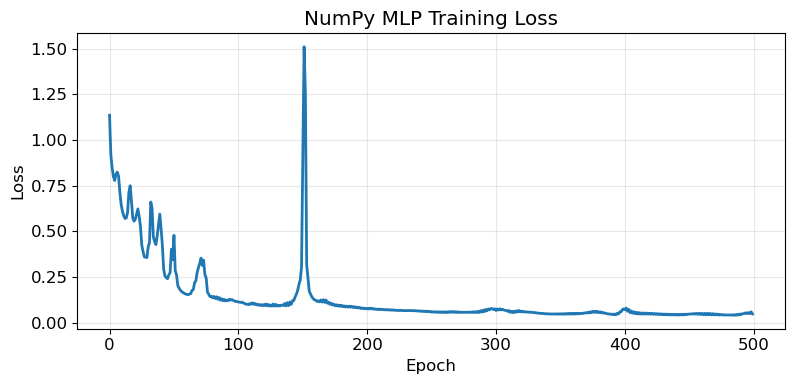

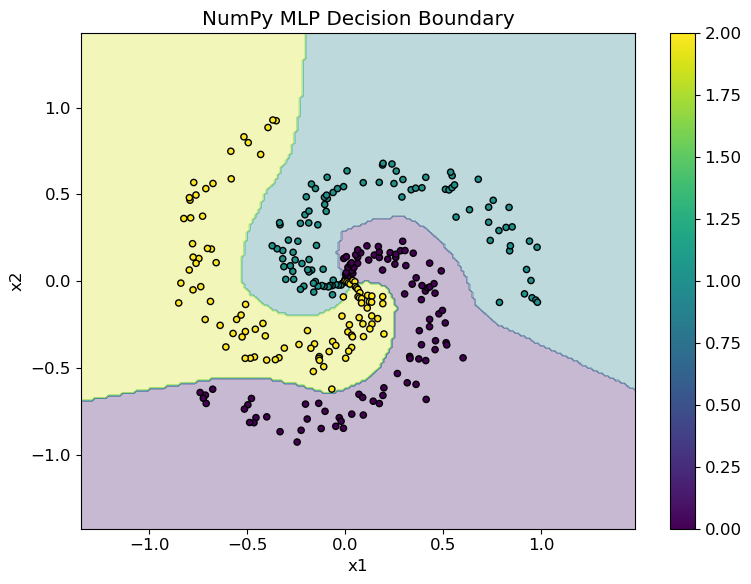

In [40]:
try:
    mlp = NumpyMLP([2, 32, 32, 3], seed=42)
    losses = train_numpy_mlp(mlp, X_train, y_train, lr=1.0, n_epochs=500)
    plot_training_loss(losses, title="NumPy MLP Training Loss")
    plot_decision_boundary_2d(X_train, y_train, model=mlp, title="NumPy MLP Decision Boundary")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

---
## Section 4: Introduction to PyTorch

PyTorch automates what we just did manually:
- **`torch.Tensor`** — like numpy arrays but with automatic differentiation
- **`nn.Module`** — base class for neural network layers
- **`nn.Linear`** — linear layer (handles weights, bias, and gradients)
- **`nn.CrossEntropyLoss`** — combines softmax + cross-entropy (numerically stable)
- **`optim.SGD`** — SGD optimizer

Let's reimplement our MLP using PyTorch and see how much simpler it is!

### Exercise 4.1: TorchMLP

Implement the same MLP architecture using `nn.Module`.

**Note:** Do NOT include softmax in `forward()` — PyTorch's `nn.CrossEntropyLoss` handles it internally.

In [41]:
class TorchMLP(nn.Module):
    """Multi-layer perceptron using PyTorch.

    Architecture: Linear -> ReLU -> Linear -> ReLU -> ... -> Linear

    Note: No softmax in forward() -- PyTorch's CrossEntropyLoss
    applies log-softmax internally.

    Parameters
    ----------
    layer_sizes : list of int
        Sizes of each layer including input and output.
    """

    def __init__(self, layer_sizes):
        super().__init__()
        # YOUR CODE HERE
        # Create self.layers as nn.Sequential of nn.Linear and nn.ReLU
        # raise NotImplementedError("Implement TorchMLP.__init__")
        layers = []
        for i in range(len(layer_sizes) - 2):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1]))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        """Forward pass. Returns logits (no softmax)."""
        # YOUR CODE HERE
        # raise NotImplementedError("Implement TorchMLP.forward")
        return self.layers(x)
    
    def predict(self, X_numpy):
        """Predict class labels from numpy array."""
        self.eval()
        with torch.no_grad():
            x = torch.tensor(X_numpy, dtype=torch.float32)
            logits = self.forward(x)
            return logits.argmax(dim=1).numpy()

### Exercise 4.2: PyTorch Training Loop

Implement the standard PyTorch training loop:
1. Convert data to tensors
2. `optimizer.zero_grad()`
3. Forward pass
4. Compute loss
5. `loss.backward()`
6. `optimizer.step()`

In [42]:
def train_torch_mlp(model, X_numpy, y_numpy, lr=0.1, n_epochs=100):
    """Train a TorchMLP model.

    Parameters
    ----------
    model : TorchMLP
    X_numpy : np.ndarray of shape (n_samples, input_size)
    y_numpy : np.ndarray of shape (n_samples,)
    lr : float
    n_epochs : int

    Returns
    -------
    losses : list of float
    """
    # YOUR CODE HERE
    # Convert data to torch tensors
    # Use nn.CrossEntropyLoss and optim.SGD
    # Standard training loop: zero_grad, forward, loss, backward, step
    # raise NotImplementedError("Implement train_torch_mlp")

    X = torch.tensor(X_numpy, dtype=torch.float32)
    y = torch.tensor(y_numpy, dtype=torch.long)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        logits = model.forward(X)
        loss = criterion(logits, y)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
    return losses

In [43]:
try:
    torch.manual_seed(42)
    test_tmodel = TorchMLP([2, 8, 3])
    test_tlosses = train_torch_mlp(test_tmodel, X_train, y_train, lr=0.5, n_epochs=200)
    assert len(test_tlosses) == 200
    assert test_tlosses[-1] < test_tlosses[0], "Loss should decrease"
    t_acc = np.mean(test_tmodel.predict(X_train) == y_train)
    assert t_acc > 0.5, f"Accuracy too low: {t_acc:.2%}"
    print(f"TorchMLP accuracy: {t_acc:.2%}")
    print("train_torch_mlp tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

TorchMLP accuracy: 59.67%
train_torch_mlp tests passed! ✓


### Run Tests for TorchMLP

Testing TorchMLP...


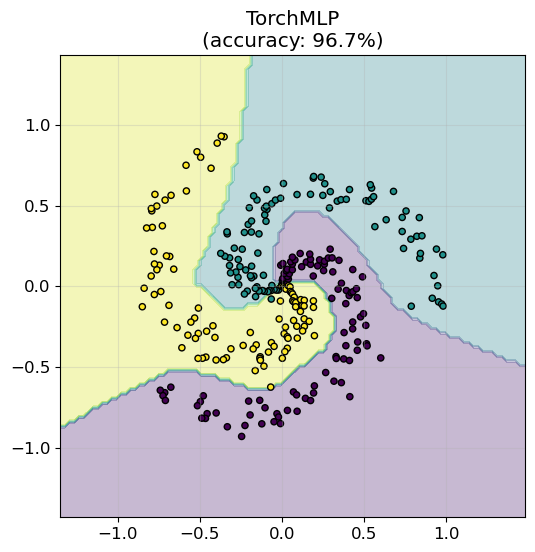

  ✓ forward_shape
  ✓ parameter_count
  ✓ training_loss_decreases
  ✓ accuracy
  ✓ matches_numpy_accuracy

TorchMLP: 5/5 tests passed
🎉 All tests passed!


In [44]:
try:
    run_single_test(TorchMLP, check_torch_mlp)
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

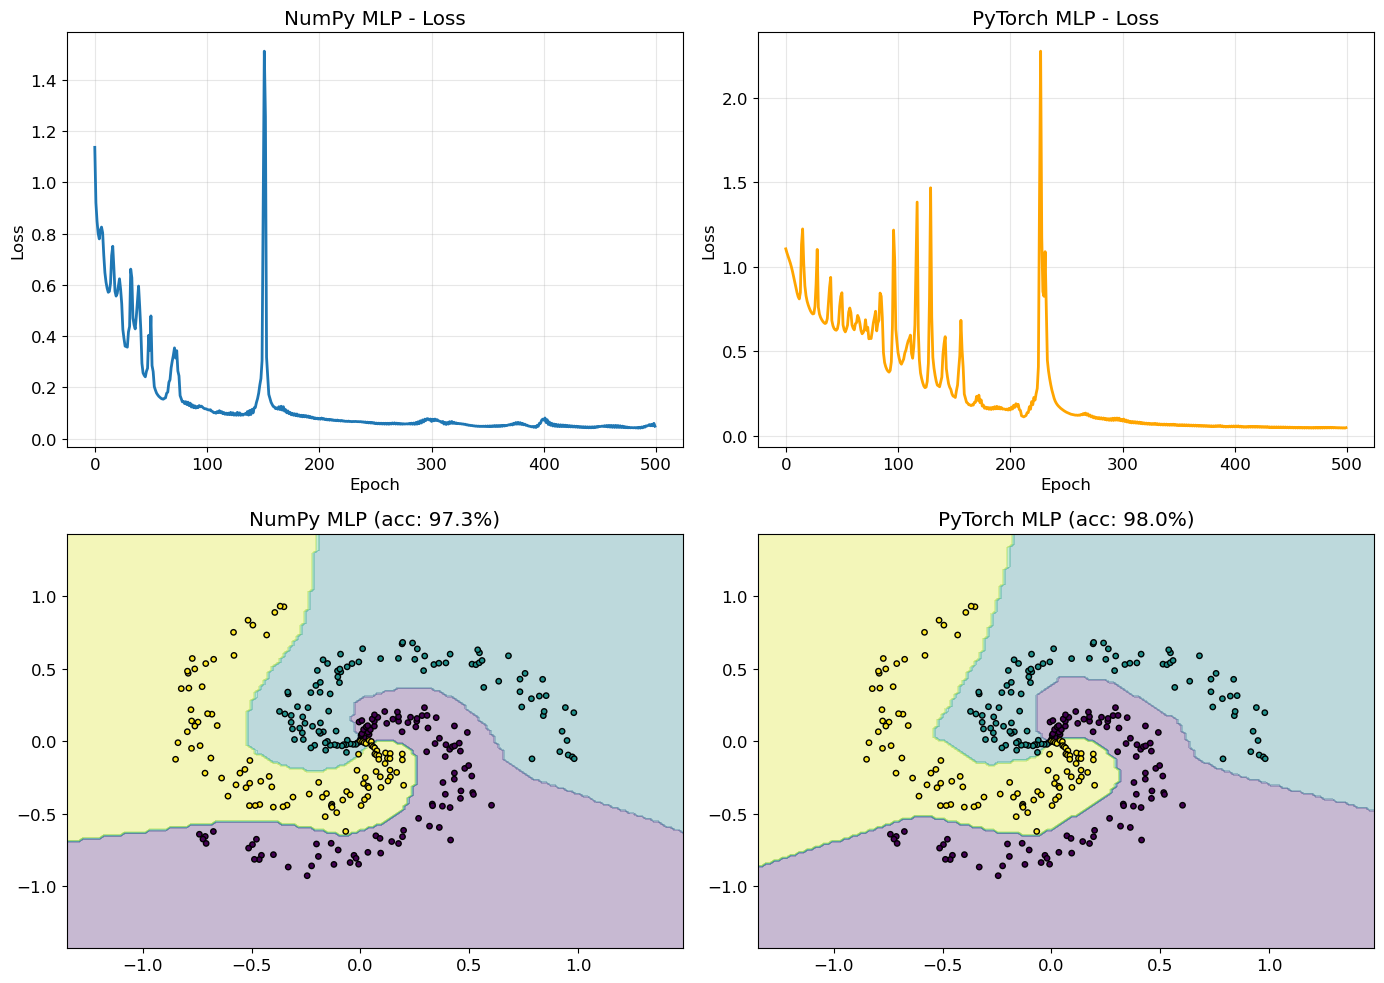

In [45]:
try:
    torch.manual_seed(42)
    torch_model = TorchMLP([2, 32, 32, 3])
    torch_losses = train_torch_mlp(torch_model, X_train, y_train, lr=1.0, n_epochs=500)
    plot_numpy_vs_torch_comparison(losses, torch_losses, mlp, torch_model, X_train, y_train)
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

---
## Section 5: Attention Mechanism

**Attention** is the key innovation behind Transformers. It allows each position in a sequence to "attend" to all other positions.

**Scaled Dot-Product Attention:**
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

where:
- $Q$ (queries), $K$ (keys), $V$ (values) are linear projections of the input
- $d_k$ is the dimension of the keys (used for scaling)

**Multi-Head Attention** runs multiple attention operations in parallel (each with different learned projections), then concatenates and projects the results.

### Exercise 5.1: Scaled Dot-Product Attention

Implement the attention formula. The `mask` parameter specifies which positions to block — fill masked positions with $-\infty$ before softmax. This is how **causal masking** works — preventing a position from attending to future positions.

**Convention:** `mask[i, j] = True` means "position i cannot attend to position j".

In [46]:
def scaled_dot_product_attention(Q, K, V, mask):
    """Compute scaled dot-product attention.

    Parameters
    ----------
    Q : torch.Tensor of shape (batch_size, n_queries, d_k)
    K : torch.Tensor of shape (batch_size, n_keys, d_k)
    V : torch.Tensor of shape (batch_size, n_keys, d_v)
    mask : torch.Tensor of shape (..., n_queries, n_keys)
        Positions where mask is True are filled with -inf
        before softmax (causal masking).

    Returns
    -------
    output : torch.Tensor of shape (batch_size, n_queries, d_v)
    attn_weights : torch.Tensor of shape (batch_size, n_queries, n_keys)
    """
    # YOUR CODE HERE
    # raise NotImplementedError("Implement scaled_dot_product_attention")

    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / np.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    attn_weights = torch.softmax(scores, dim=-1)
    output = attn_weights @ V
    return output, attn_weights

In [47]:
try:
    torch.manual_seed(0)
    Q = torch.randn(2, 3, 4)  # batch=2, queries=3, d_k=4
    K = torch.randn(2, 5, 4)  # batch=2, keys=5, d_k=4
    V = torch.randn(2, 5, 6)  # batch=2, keys=5, d_v=6
    # No masking: use all-False mask (nothing blocked)
    no_mask = torch.zeros(3, 5, dtype=torch.bool)
    out, weights = scaled_dot_product_attention(Q, K, V, mask=no_mask)
    assert out.shape == (2, 3, 6), f"Output shape: expected (2,3,6), got {out.shape}"
    assert weights.shape == (2, 3, 5), f"Weights shape: expected (2,3,5), got {weights.shape}"
    assert torch.allclose(weights.sum(dim=-1), torch.ones(2, 3), atol=1e-6), "Weights must sum to 1"
    # Test causal masking
    mask = torch.triu(torch.ones(3, 5, dtype=torch.bool), diagonal=1)
    out_m, weights_m = scaled_dot_product_attention(Q, K, V, mask=mask)
    print("scaled_dot_product_attention tests passed! ✓")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

scaled_dot_product_attention tests passed! ✓


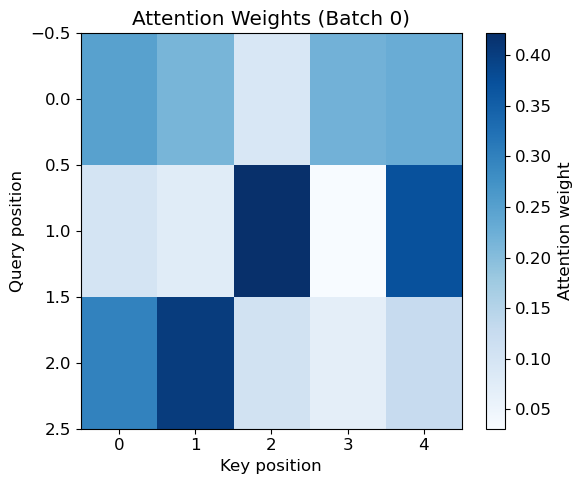

In [48]:
try:
    plot_attention_weights(weights[0].detach().numpy(), title="Attention Weights (Batch 0)")
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

### Exercise 5.2: Multi-Head Attention

**Multi-Head Attention** splits the input into multiple "heads", runs attention on each head independently, then concatenates and projects the results.

**Steps:**
1. Project $Q$, $K$, $V$ through linear layers: $W_q$, $W_k$, $W_v$
2. Reshape to `(batch, n_heads, seq_len, d_k)` where `d_k = d_model // n_heads`
3. Apply `scaled_dot_product_attention` to each head
4. Reshape back to `(batch, seq_len, d_model)` and project through $W_o$

In [51]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention mechanism.

    Parameters
    ----------
    d_model : int
        Model dimensionality (input and output size).
    n_heads : int
        Number of attention heads. Must divide d_model evenly.
    """

    def __init__(self, d_model, n_heads):
        super().__init__()
        # YOUR CODE HERE
        # Create linear projections: W_q, W_k, W_v, W_o
        # Each should be nn.Linear(d_model, d_model)
        # raise NotImplementedError("Implement MultiHeadAttention.__init__")
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, Q, K, V, mask):
        """Forward pass.

        Parameters
        ----------
        Q : torch.Tensor of shape (batch_size, seq_len_q, d_model)
        K : torch.Tensor of shape (batch_size, seq_len_k, d_model)
        V : torch.Tensor of shape (batch_size, seq_len_k, d_model)
        mask : torch.Tensor of shape (..., seq_len_q, seq_len_k)
            Causal mask. True = blocked.

        Returns
        -------
        output : torch.Tensor of shape (batch_size, seq_len_q, d_model)
        attn_weights : torch.Tensor of shape (batch_size, n_heads, seq_len_q, seq_len_k)
        """
        # YOUR CODE HERE
        # 1. Project Q, K, V through linear layers
        # 2. Reshape to (batch, n_heads, seq_len, d_k) where d_k = d_model // n_heads
        # 3. Apply scaled_dot_product_attention
        # 4. Reshape back and project through W_o
        # raise NotImplementedError("Implement MultiHeadAttention.forward")


        batch_size = Q.size(0)
        # 1. Linear projections
        Q_proj = self.W_q(Q)  # (batch_size, seq_len_q, d_model)
        K_proj = self.W_k(K)  # (batch_size, seq_len_k, d_model)
        V_proj = self.W_v(V)  # (batch_size, seq_len_k, d_model)        

        # 2. Reshape for multi-head: (batch_size, seq_len, n_heads, d_k) -> (batch_size, n_heads, seq_len, d_k)
        Q_proj = Q_proj.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K_proj = K_proj.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V_proj = V_proj.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)    
        # 3. Scaled dot-product attention
        attn_output, attn_weights = scaled_dot_product_attention(Q_proj, K_proj, V_proj, mask)
        # attn_output: (batch_size, n_heads, seq_len_q, d_k)
        # attn_weights: (batch_size, n_heads, seq_len_q, seq_len_k) 

        # 4. Reshape back: (batch_size, seq_len_q, n_heads * d_k) = (batch_size, seq_len_q, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(attn_output)
        return output, attn_weights

### Run Tests for MultiHeadAttention

Testing MultiHeadAttention...


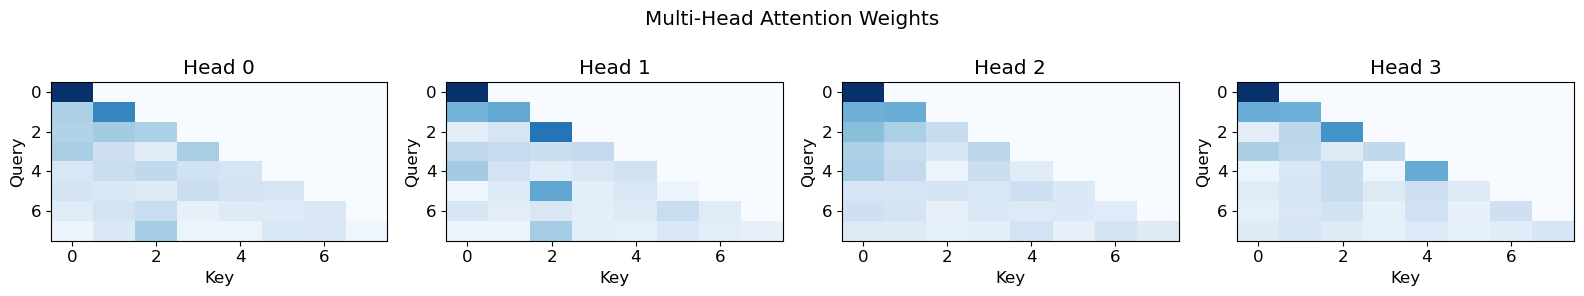

  ✓ output_shape
  ✓ attn_weights_shape
  ✓ attn_weights_sum_to_one
  ✓ causal_mask_works
  ✓ multi_head_output_differs_from_single

MultiHeadAttention: 5/5 tests passed
🎉 All tests passed!


In [52]:
try:
    run_single_test(MultiHeadAttention, check_multi_head_attention)
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

---
## Section 6: Transformer Block

A **Transformer block** combines multi-head attention with a feed-forward network, using **residual connections** and **layer normalization**:

```
x → MultiHeadAttention → Add & LayerNorm → FFN → Add & LayerNorm → out
```

**Residual connections** ($x + f(x)$) help gradient flow through deep networks.
**Layer normalization** normalizes activations along the feature dimension, stabilizing training.

### Exercise 6.1: Transformer Block

Implement the transformer block with:
- Self-attention (Q=K=V=x)
- Post-norm architecture: `LayerNorm(x + sublayer(x))`
- Feed-forward network: `Linear → ReLU → Linear`

In [53]:
class TransformerBlock(nn.Module):
    """Single transformer block.

    Architecture:
        x -> MultiHeadAttention -> Add & LayerNorm -> FFN -> Add & LayerNorm -> out

    Parameters
    ----------
    d_model : int
        Model dimensionality.
    n_heads : int
        Number of attention heads.
    d_ff : int
        Hidden size of the feed-forward network.
    """

    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        # YOUR CODE HERE
        # Create: self.attention (MultiHeadAttention), self.norm1, self.norm2 (LayerNorm),
        # self.ffn (Sequential: Linear -> ReLU -> Linear)
        # raise NotImplementedError("Implement TransformerBlock.__init__")

        self.attention = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),  
            nn.Linear(d_ff, d_model)    
        )

        
    def forward(self, x, mask):
        """Forward pass.

        Parameters
        ----------
        x : torch.Tensor of shape (batch_size, seq_len, d_model)
        mask : torch.Tensor of shape (..., seq_len, seq_len)
            Causal mask. True = blocked.

        Returns
        -------
        out : torch.Tensor of shape (batch_size, seq_len, d_model)
        """
        # YOUR CODE HERE
        # raise NotImplementedError("Implement TransformerBlock.forward")

        attn_output, _ = self.attention(x, x, x, mask)
        x = self.norm1(x + attn_output)  # Add & LayerNorm
        ffn_output = self.ffn(x)
        out = self.norm2(x + ffn_output)  # Add & LayerNorm
        return out

### Run Tests for TransformerBlock

In [54]:
try:
    run_single_test(TransformerBlock, check_transformer_block)
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

Testing TransformerBlock...
  ✓ output_shape
  ✓ residual_connection
  ✓ layer_norm_applied
  ✓ different_seq_lengths

TransformerBlock: 4/4 tests passed
🎉 All tests passed!


---
## Section 7: Transformer Language Model

Now let's build a complete **character-level language model** using our transformer blocks!

**Character-level LM:** Given a sequence of characters, predict the next character at each position.

**Causal masking:** Each position can only attend to positions **before** it (not the future). This is achieved by masking the upper triangle of the attention matrix.

**Architecture:**
1. Token embedding + positional embedding
2. Stack of transformer blocks (with causal mask)
3. Layer norm + linear projection to vocabulary size

### Data Preparation

We'll use a tiny excerpt from Shakespeare (250 characters). This is small enough to train on CPU in under a second.

In [55]:
try:
    text, char_to_idx, idx_to_char, vocab_size = generate_tiny_text_data()
    encoded = encode_text(text, char_to_idx)
    X_text = encoded[:-1].unsqueeze(0)  # (1, seq_len)
    y_text = encoded[1:].unsqueeze(0)  # (1, seq_len)
    print(f"Vocabulary size: {vocab_size}")
    print(f"Dataset: {X_text.shape[0]} sequence of length {X_text.shape[1]}")
    print(f"Text:\n{text}")
except Exception as e:
    print(f"\u26a0\ufe0f Skipped (not yet implemented or error): {e}")

Vocabulary size: 35
Dataset: 1 sequence of length 249
Text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



### Exercise 7.1: SimpleTransformer

Build a complete transformer for character-level language modeling.

**Components:**
- `nn.Embedding` for token embeddings (vocab_size → d_model)
- `nn.Embedding` for positional embeddings (max_seq_len → d_model)
- Stack of `TransformerBlock` layers
- `nn.LayerNorm` + `nn.Linear` output head (d_model → vocab_size)

**Causal mask:** Create an upper-triangular boolean mask so each position only attends to previous positions.

In [57]:
class SimpleTransformer(nn.Module):
    """Simple transformer for character-level language modeling.

    Parameters
    ----------
    vocab_size : int
    d_model : int, default=32
    n_heads : int, default=2
    n_layers : int, default=2
    d_ff : int, default=64
    max_seq_len : int, default=64
    """

    def __init__(self, vocab_size, d_model=32, n_heads=2, n_layers=2, d_ff=64, max_seq_len=64):
        super().__init__()
        # YOUR CODE HERE
        # Create: token_embedding, position_embedding, transformer blocks,
        # layer norm, and output linear head
        # raise NotImplementedError("Implement SimpleTransformer.__init__")
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.output_head = nn.Linear(d_model, vocab_size)   


    def forward(self, x):
        """Forward pass.

        Parameters
        ----------
        x : torch.LongTensor of shape (batch_size, seq_len)

        Returns
        -------
        logits : torch.Tensor of shape (batch_size, seq_len, vocab_size)
        """
        # YOUR CODE HERE
        # 1. Token embedding + positional embedding
        # 2. Pass through transformer blocks with causal mask
        # 3. Layer norm + project to vocabulary size
        # raise NotImplementedError("Implement SimpleTransformer.forward")
        batch_size, seq_len = x.size()
        token_emb = self.token_embedding(x)  # (batch_size, seq_len, d_model)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        pos_emb = self.position_embedding(positions)  # (batch_size, seq_len, d_model)
        x = token_emb + pos_emb  # (batch_size, seq_len, d_model)
        # Causal mask: (seq_len, seq_len) with True in upper triangle
        mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool, device=x.device), diagonal=1)
        for block in self.transformer_blocks:
            x = block(x, mask)
        x = self.norm(x)
        logits = self.output_head(x)  # (batch_size, seq_len, vocab_size)
        return logits

    def generate(self, start_tokens, max_new_tokens=100, temperature=1.0):
        """Generate text autoregressively.

        Parameters
        ----------
        start_tokens : torch.LongTensor of shape (1, seq_len)
        max_new_tokens : int
        temperature : float

        Returns
        -------
        tokens : torch.LongTensor of shape (1, seq_len + max_new_tokens)
        """
        # YOUR CODE HERE
        # raise NotImplementedError("Implement SimpleTransformer.generate")
        self.eval()
        tokens = start_tokens
        with torch.no_grad():   
            for _ in range(max_new_tokens):
                logits = self.forward(tokens)  # (1, seq_len, vocab_size)
                next_token_logits = logits[:, -1, :] / temperature  # (1, vocab_size)
                next_token = torch.multinomial(torch.softmax(next_token_logits, dim=-1), num_samples=1)  # (1, 1)
                tokens = torch.cat([tokens, next_token], dim=1)  # Append to sequence
        return tokens

### Run Tests for SimpleTransformer

Testing SimpleTransformer...


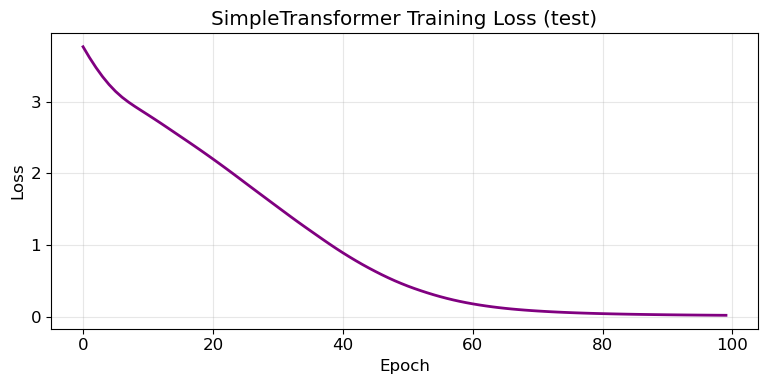

  ✓ forward_shape
  ✓ generate_shape
  ✓ overfitting
  ✓ causal_masking

SimpleTransformer: 4/4 tests passed
🎉 All tests passed!


In [58]:
try:
    run_single_test(SimpleTransformer, check_simple_transformer)
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")

### Train the Transformer

Let's train our tiny transformer on the Shakespeare text. We use the entire text as a single training sequence, so the model should **overfit** — memorizing it perfectly. This is expected and desirable here: it proves the model works!

Epoch 50/200, Loss: 0.4662
Epoch 100/200, Loss: 0.0230
Epoch 150/200, Loss: 0.0099
Epoch 200/200, Loss: 0.0060

Final loss: 0.0060
Training accuracy (next-char prediction): 100.0%


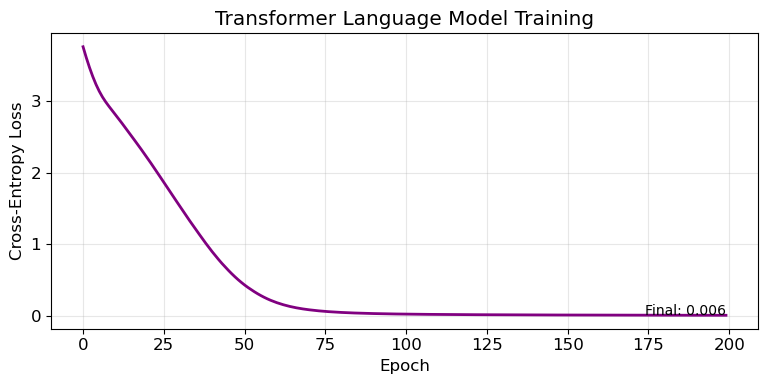

In [59]:
try:
    torch.manual_seed(42)
    transformer = SimpleTransformer(
        vocab_size=vocab_size,
        d_model=32,
        n_heads=2,
        n_layers=2,
        d_ff=64,
        max_seq_len=256,
    )
    optimizer = optim.Adam(transformer.parameters(), lr=3e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    transformer.train()
    for epoch in range(200):
        optimizer.zero_grad()
        logits = transformer(X_text)
        loss = criterion(logits.view(-1, vocab_size), y_text.view(-1))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch + 1}/200, Loss: {loss.item():.4f}")

    # Measure overfitting: next-character prediction accuracy on training data
    transformer.eval()
    with torch.no_grad():
        logits = transformer(X_text)
        preds = logits.argmax(dim=-1)
        accuracy = (preds == y_text).float().mean().item()
    print(f"\nFinal loss: {train_losses[-1]:.4f}")
    print(f"Training accuracy (next-char prediction): {accuracy:.1%}")

    plot_transformer_training(train_losses)
except Exception as e:
    print(f"\u26a0\ufe0f Skipped (not yet implemented or error): {e}")

### Generate Text

Since the model has memorized the training data, generating from just the first character should reproduce the entire text.

In [60]:
try:
    # The model has memorized the training text — generate from the first character
    start = encode_text(text[0], char_to_idx).unsqueeze(0)
    generated = transformer.generate(start, max_new_tokens=len(text) - 1, temperature=0.1)
    gen_text = decode_text(generated[0], idx_to_char)
    print("Generated text:")
    print(gen_text)
    print(f"\nOriginal text:")
    print(text)
    match = sum(a == b for a, b in zip(gen_text, text))
    print(f"\nCharacter match: {match}/{len(text)} ({match / len(text):.0%})")
except Exception as e:
    print(f"\u26a0\ufe0f Skipped (not yet implemented or error): {e}")

Generated text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.


Original text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.


Character match: 250/250 (100%)


---
## Section 8: Summary & Key Takeaways

| Component | Framework | Key Concept |
|-----------|-----------|-------------|
| Linear Forward/Backward | NumPy | Chain rule, gradient computation |
| ReLU Forward/Backward | NumPy | Piecewise gradient (0 or 1) |
| Softmax + Cross-Entropy | NumPy | Combined gradient = (probs - one_hot) / N |
| NumpyMLP | NumPy | Forward caching, backward propagation |
| SGD | NumPy | Simplest optimizer: θ -= lr * grad |
| TorchMLP | PyTorch | nn.Module, autograd, optimizer |
| Scaled Dot-Product Attention | PyTorch | QK^T/√d_k, causal masking |
| Multi-Head Attention | PyTorch | Parallel attention with different projections |
| Transformer Block | PyTorch | Attention + FFN + residual + layer norm |
| SimpleTransformer | PyTorch | Complete language model with generation |

**Key insights:**
- Backpropagation is just the chain rule applied systematically
- PyTorch automates gradient computation — same math, less code
- Attention allows flexible, content-dependent information routing
- Transformers stack attention + FFN blocks with residual connections
- Even a tiny transformer can learn patterns in text!

---
## Section 9: Run All Tests


Testing NumpyMLP


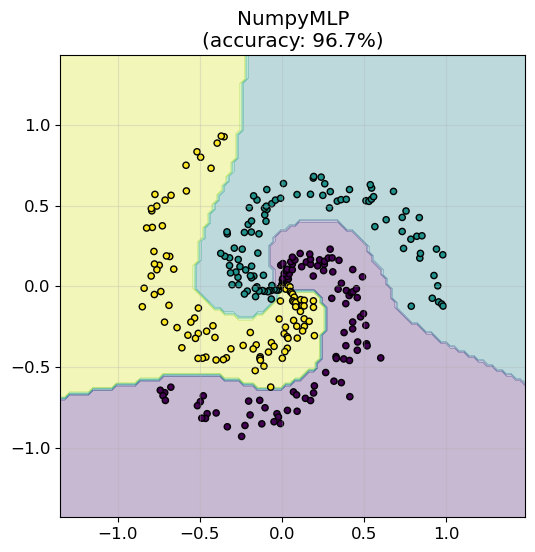

  ✓ forward_shape: PASSED
  ✓ backward_shapes: PASSED
  ✓ gradient_check: PASSED
  ✓ training_loss_decreases: PASSED
  ✓ accuracy: PASSED

  NumpyMLP: 5/5 tests passed

Testing TorchMLP


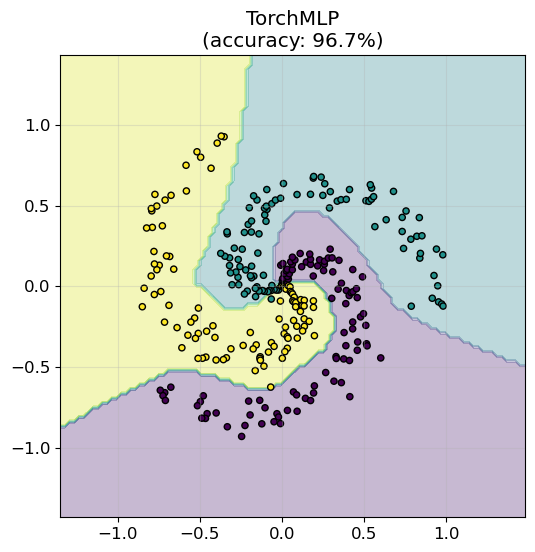

  ✓ forward_shape: PASSED
  ✓ parameter_count: PASSED
  ✓ training_loss_decreases: PASSED
  ✓ accuracy: PASSED
  ✓ matches_numpy_accuracy: PASSED

  TorchMLP: 5/5 tests passed

Testing MultiHeadAttention


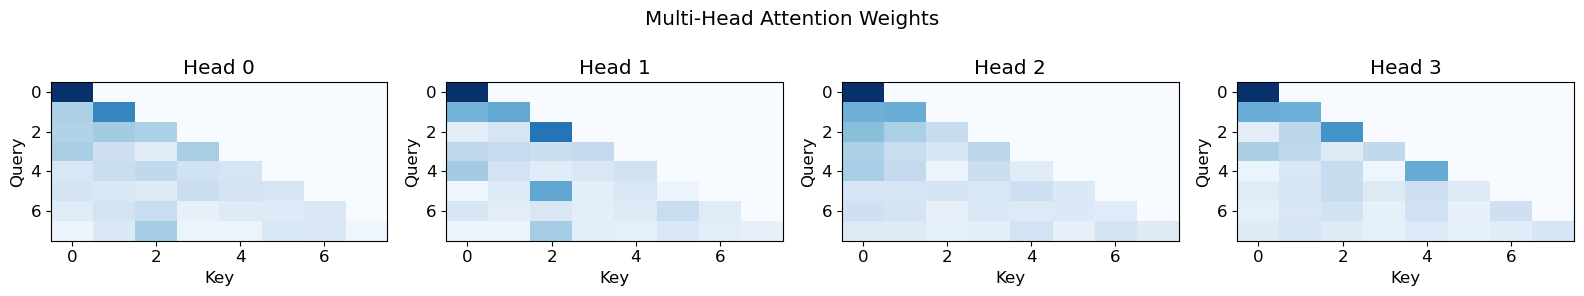

  ✓ output_shape: PASSED
  ✓ attn_weights_shape: PASSED
  ✓ attn_weights_sum_to_one: PASSED
  ✓ causal_mask_works: PASSED
  ✓ multi_head_output_differs_from_single: PASSED

  MultiHeadAttention: 5/5 tests passed

Testing TransformerBlock
  ✓ output_shape: PASSED
  ✓ residual_connection: PASSED
  ✓ layer_norm_applied: PASSED
  ✓ different_seq_lengths: PASSED

  TransformerBlock: 4/4 tests passed

Testing SimpleTransformer


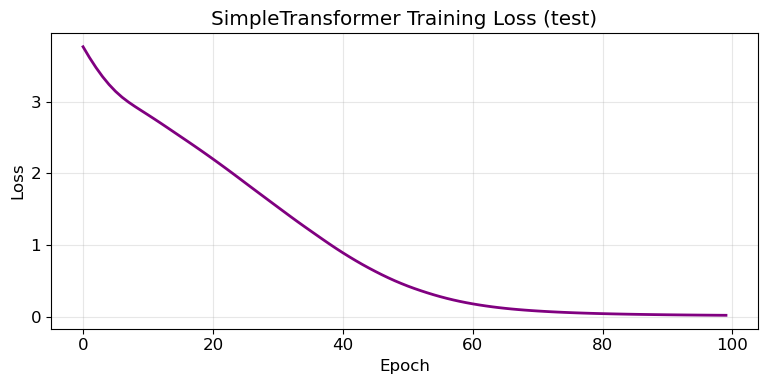

  ✓ forward_shape: PASSED
  ✓ generate_shape: PASSED
  ✓ overfitting: PASSED
  ✓ causal_masking: PASSED

  SimpleTransformer: 4/4 tests passed

TOTAL: 23 passed, 0 failed


In [61]:
try:
    run_tests(
        NumpyMLPClass=NumpyMLP,
        TorchMLPClass=TorchMLP,
        MultiHeadAttentionClass=MultiHeadAttention,
        TransformerBlockClass=TransformerBlock,
        SimpleTransformerClass=SimpleTransformer,
    )
except Exception as e:
    print(f"⚠️ Skipped (not yet implemented or error): {e}")